<a href="https://colab.research.google.com/github/Rasool-4376/CV_lab7/blob/main/CV_lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

In [ ]:
def filtering(img, kernel, p, s):
    m, n = img.shape
    x, y = kernel.shape

    rows = (m - x + 2 * p) // s + 1
    cols = (n - y + 2 * p) // s + 1

    padded_img = np.pad(img, p, constant_values=0)

    output = np.zeros((rows, cols))

    for i in range(rows):
        for j in range(cols):
            output[i][j] = np.sum(
                padded_img[i*s:i*s+x, j*s:j*s+y] * kernel
            )

    return output

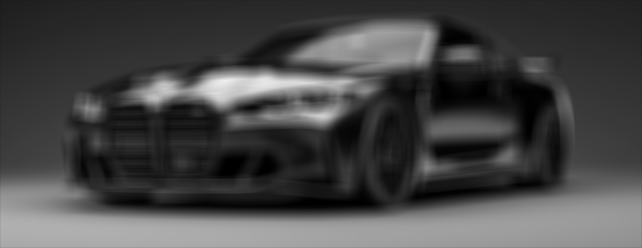

In [ ]:
from google.colab.patches import cv2_imshow

k = 15
p = 1
s = 1

img = cv2.imread("/content/drive/MyDrive/car.jpg", 0)

kernel = np.ones((k, k)) / k**2

filtered_output = filtering(img, kernel, p, s)

cv2_imshow(filtered_output.astype(np.uint8))

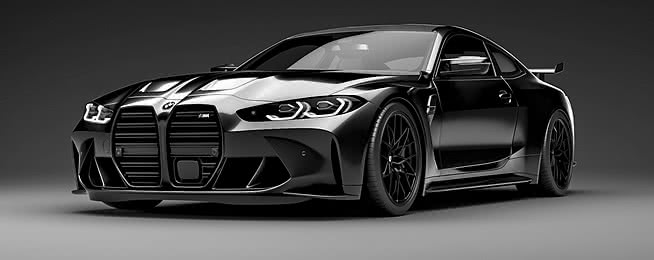

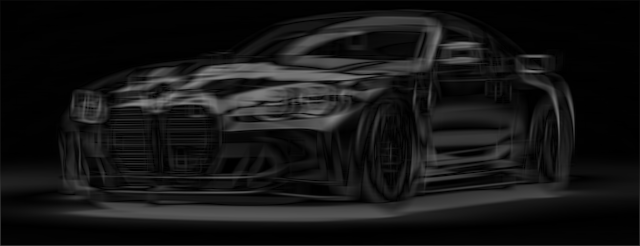

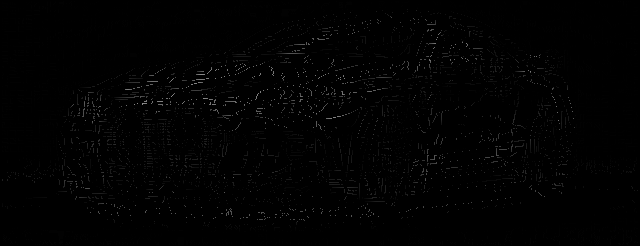

In [ ]:
sobel_kernel_x = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

sobel_kernel_y = sobel_kernel_x.T

filtered_image_x = filtering(
    filtered_output, sobel_kernel_x, p=0, s=1
)

filtered_image_y = filtering(
    filtered_output, sobel_kernel_y, p=0, s=1
)

mag_filtered_img = np.sqrt(
    filtered_image_x**2 + filtered_image_y**2
)

angle_filtered_img = np.degrees(
    np.arctan2(filtered_image_y, filtered_image_x)
)


angle_filtered_img[angle_filtered_img < 0] += 180


angle_quantized = np.zeros_like(angle_filtered_img)

for i in range(angle_filtered_img.shape[0]):
    for j in range(angle_filtered_img.shape[1]):

        angle = angle_filtered_img[i, j]

        if (-22.5 <= angle < 22.5) or (157.5 <= angle <= 180):
            angle_quantized[i, j] = 0

        elif 22.5 <= angle < 67.5:
            angle_quantized[i, j] = 45

        elif 67.5 <= angle < 112.5:
            angle_quantized[i, j] = 90

        elif 112.5 <= angle < 157.5:
            angle_quantized[i, j] = 135

nms = np.zeros_like(mag_filtered_img)

rows, cols = mag_filtered_img.shape

for i in range(1, rows - 1):
    for j in range(1, cols - 1):

        angle = angle_quantized[i, j]

        if angle == 0:
            p1 = mag_filtered_img[i, j-1]
            p2 = mag_filtered_img[i, j+1]


        elif angle == 45:
            p1 = mag_filtered_img[i-1, j+1]
            p2 = mag_filtered_img[i+1, j-1]

        elif angle == 90:
            p1 = mag_filtered_img[i-1, j]
            p2 = mag_filtered_img[i+1, j]


        else:
            p1 = mag_filtered_img[i-1, j-1]
            p2 = mag_filtered_img[i+1, j+1]

        if mag_filtered_img[i, j] >= p1 and \
           mag_filtered_img[i, j] >= p2:

            nms[i, j] = mag_filtered_img[i, j]

        else:
            nms[i, j] = 0

if img is not None:
    cv2_imshow(img)
cv2_imshow(mag_filtered_img.astype(np.uint8))
cv2_imshow(nms.astype(np.uint8))